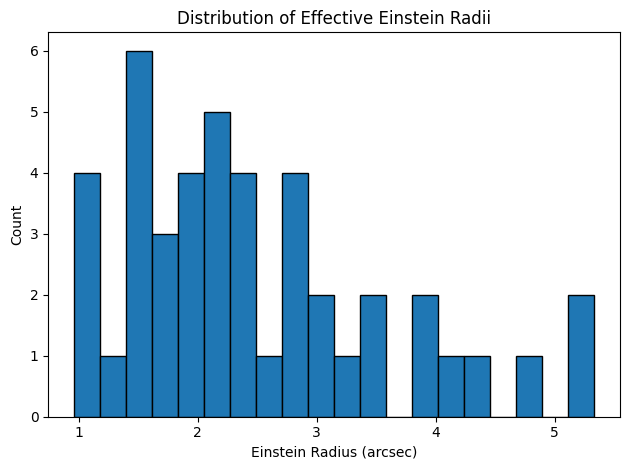

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("einstein_radii.csv")

plt.figure()
plt.hist(df["einstein_radius_arcsec"], bins=20, edgecolor="black")
plt.xlabel("Einstein Radius (arcsec)")
plt.ylabel("Count")
plt.title("Distribution of Effective Einstein Radii")
plt.tight_layout()
plt.savefig("einstein_radii_histogram.png", dpi=300)
plt.show()

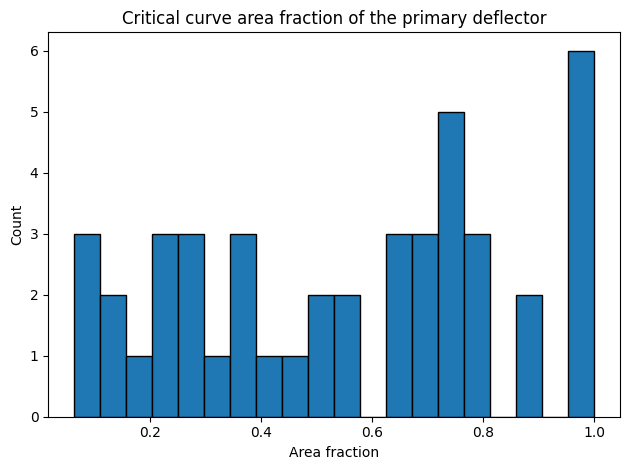

In [9]:
C = df["primary_einstein_radius_arcsec"]**2 / df["einstein_radius_arcsec"]**2

plt.figure()
plt.hist(C, bins=20, edgecolor="black")
plt.xlabel("Area fraction")
plt.ylabel("Count")
plt.title("Critical curve area fraction of the primary deflector")
plt.tight_layout()
plt.savefig("primary_deflector_relative_contribution_histogram.png", dpi=300)
plt.show()

In [7]:
max(C)

1.0

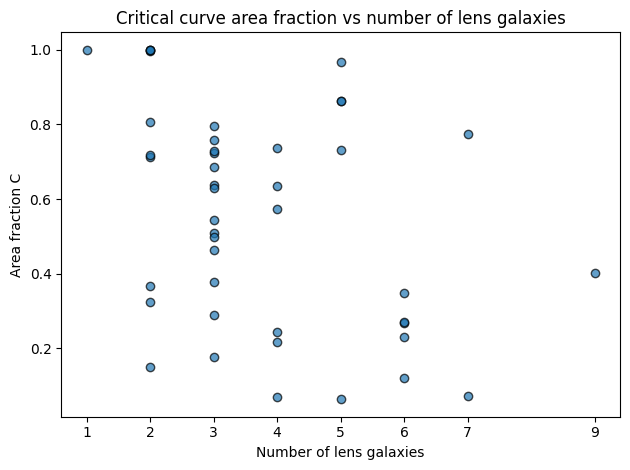

In [10]:
plt.figure()
plt.scatter(df["n_galaxies"], C, edgecolor="black", alpha=0.7)
plt.xlabel("Number of lens galaxies")
plt.ylabel("Area fraction C")
plt.title("Critical curve area fraction vs number of lens galaxies")
plt.xticks(df["n_galaxies"].unique())  # only show integer ticks that exist in the data
plt.tight_layout()
plt.savefig("area_fraction_vs_n_galaxies.png", dpi=300)
plt.show()

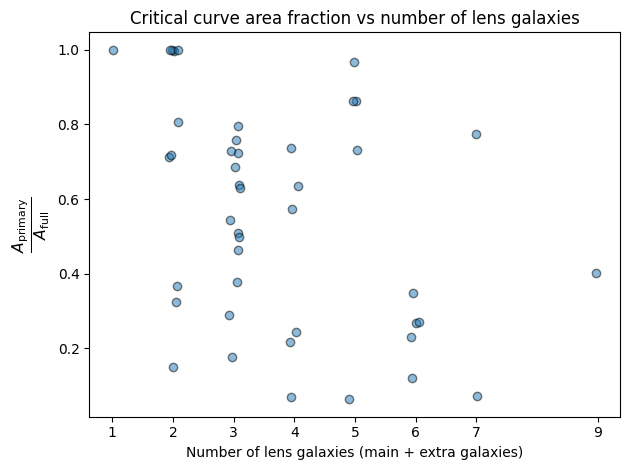

In [49]:
jitter = np.random.uniform(-0.1, 0.1, size=len(df))

plt.figure()
plt.scatter(df["n_galaxies"] + jitter, C, edgecolor="black", alpha=0.5)
plt.xlabel("Number of lens galaxies (main + extra galaxies)")
plt.ylabel(
    r"$\frac{A_\mathrm{primary}}{A_\mathrm{full}}$",
    fontsize=16
)
plt.title("Critical curve area fraction vs number of lens galaxies")
plt.xticks(df["n_galaxies"].unique())  # only show integer ticks that exist in the data
plt.tight_layout()
plt.savefig("area_fraction_vs_n_galaxies.png", dpi=300)
plt.show()

C:\Users\c4072114\AppData\Local\Temp\ipykernel_16912\2749260062.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("YlOrRd", n_levels)


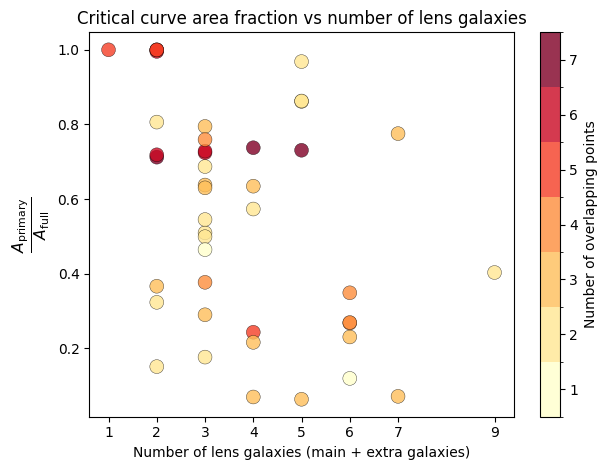

In [47]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

df = pd.read_csv("einstein_radii.csv")

C = df["primary_einstein_radius_arcsec"]**2 / df["einstein_radius_arcsec"]**2

x = df["n_galaxies"].values.astype(float)
y = C.values

# Count how many points are within a small radius of each point
radius_y = 0.03  # in units of C
counts = np.array([
    np.sum(np.abs(y - yi) < radius_y)
    for yi in y
])

# Discrete colourmap
max_count = counts.max()
n_levels = min(max_count, 10)  # cap at 10 colour levels
cmap = get_cmap("YlOrRd", n_levels)
bounds = np.arange(0.5, n_levels + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()
scatter = ax.scatter(
    x, y,
    c=counts,
    cmap=cmap,
    norm=norm,
    s=100,  # larger points
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
)
cbar = plt.colorbar(scatter, ax=ax, label="Number of overlapping points")
cbar.set_ticks(np.arange(1, n_levels + 1))
ax.set_xlabel("Number of lens galaxies (main + extra galaxies)")
plt.ylabel(
    r"$\frac{A_\mathrm{primary}}{A_\mathrm{full}}$",
    fontsize=16
)
ax.set_title("Critical curve area fraction vs number of lens galaxies")
ax.set_xticks(df["n_galaxies"].unique())
plt.tight_layout()
plt.savefig("area_fraction_vs_n_galaxies.png", dpi=300)
plt.show()